# Figure 11 Average Feature Importance $\Delta\!$ MLat Fit Removed
In this notebook we show how perform the feature importance to find the predictive power of different variables for $\Delta\!$ MLat after the removal of the linear dipole tilt fit
This notebook produces Figure 9 in the related paper.

## Imports
First we import the functions we need

In [1]:
from multiprocessing import Pool # We use this to speed up the code by performing operations at the same time on different cpus
from sklearn.model_selection import train_test_split # This allows us to sample our dataset
from sklearn.ensemble import RandomForestRegressor # Key component for feature importance
from sklearn.metrics import mean_squared_error, mean_absolute_error # For quantify the goodness of fit 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import iqr # interquartile range
from Boxplot import add_boxkey # Used to make a box plot key in figure
# plt.style.use('dark_background')

## Settings
settings needed for all the plotting

In [2]:
colors= ['#003f5c', '#bc5090', '#ffa600']

medianprops={'color':colors[0], 'lw':2}
meanprops= {'color':colors[1], 'lw':2}
boxplot={'medianprops':medianprops, 'meanprops':meanprops}
barchart={'color':colors[2]}

# Loading Dataset
Loading Onset file and created $\Delta\!$ MLT column

In [3]:
Onsets= pd.read_csv('../Data/Mediated_Onsets.csv', parse_dates=['Date_NH'])
Onsets= Onsets[Onsets.flag==1][['Date_NH', 'Frey_MLT', 'Frey_MLAT', 'MLAT_SH']]
Onsets.loc[Onsets.Frey_MLT<12, 'Frey_MLT']+=24
Onsets['DMLAT']=Onsets['MLAT_SH']-Onsets['Frey_MLAT']

## Rounding Time
Rounding the NH image time to the nearest minute

In [4]:
diff= Onsets.Date_NH-Onsets.Date_NH.values.astype('datetime64[m]')
delta= np.zeros(diff.shape).astype('timedelta64[m]')
delta[diff.values>=np.timedelta64(30, 's')]=np.timedelta64(1, 'm')
Onsets['Date_UTC']=Onsets.Date_NH.values.astype('datetime64[m]').astype('datetime64[ns]')+delta

## Loading Omni
Load the omni data and set values to 'NaN' when the required number of data points in the window is not satisfied.

In [5]:
omni= pd.read_hdf('../Data/omni_data.hdf5', key='omni_window_2h_20')
omni.loc[omni['points_BZ_GSM']<120*.9, ['BX_GSE_Mean','BY_GSM_Mean',
                                 'BZ_GSM_Mean','Clock_GSM_SEM',
                                 'Clock_GSM_Mean']]=np.nan
omni['Date_UTC']= omni.index.values
omni.index= list(range(len(omni)))

## Merging Omni and Onset dataframes using the time column
We also calculate the sin and cosine of the clock angle (bow shock only) and the mean clock angle (window averaged and time shifted)

In [6]:
Onsets= Onsets.merge(omni, on='Date_UTC')

Onsets['Sin(Clock_GSM_Mean)']= np.sin(Onsets.Clock_GSM_Mean)
Onsets['Cos(Clock_GSM_Mean)']= np.cos(Onsets.Clock_GSM_Mean)
Onsets['Sin(Clock_GSM)']= np.sin(Onsets.Clock_GSM)
Onsets['Cos(Clock_GSM)']= np.cos(Onsets.Clock_GSM)


## Selecting Feature Columns

In [7]:
columns= ['Cos(Clock_GSM)', 'Sin(Clock_GSM)', 
'BZ_GSM',
          'Cos(Clock_GSM_Mean)', 'Sin(Clock_GSM_Mean)',
          'BX_GSE_Mean','BY_GSM_Mean', 'BZ_GSM_Mean',
           'AL_INDEX', 'AU_INDEX', 'ASY_H', 'SYM_H', 'Dipole_Tilt', 'Vx', 'Vy', 'Vz']
# Fixing decimal accuracy as sometimes unphysical accuracy appears
for col in ['DMLAT', 'Frey_MLT']+columns:
    Onsets[col]= np.round(Onsets[col], 15)

## Creating Random Feature
We fix the seed so the results are reproducable

In [8]:
np.random.seed(42)
Onsets['Random']= np.random.uniform(0, 1, size=len(Onsets))

## Fit Removal
We remove the linear By fit and the sine clock angle fit

In [9]:
with open('./fitting_params.txt', 'r') as fits:
    fits= eval(fits.read())

def multi_fit(x1, x2, m1, m2, c):
    return m1*x1 + m2*x2 +c

Onsets['DMLAT_Corrected']= Onsets['DMLAT']-multi_fit(Onsets['Vy'], Onsets['Dipole_Tilt'], **fits['MLAT_Dip_Vy'])

## Handling Outliers
We use 1.5 times the interquartile range over and under the upper and lower quartiles to define outliers and exclude them from feature importance

In [10]:
# Outliers
upper_lim= Onsets.DMLAT<np.quantile(Onsets.DMLAT, .75)+iqr(Onsets.DMLAT)*1.5
lower_lim= Onsets.DMLAT>np.quantile(Onsets.DMLAT, .25)-iqr(Onsets.DMLAT)*1.5
rm_out= upper_lim&lower_lim
Onsets= Onsets[rm_out&Onsets.BZ_GSM_Mean.notnull()&Onsets.BZ_GSM.notnull()&Onsets.Vx.notnull()] # we also remove rows with no bowshock omni and averaged omni (B and V) that does not have enough data points in the window

## Feature Importance Definition
We create the feature importance function and set the seeds for seed cycling and repeated cross validation.
We also define X and y where X is are features we want to find the importance for and y is the feature to predict ($\Delta\!$ MLT)

In [11]:
X= Onsets[['Random', 'Frey_MLT']+columns]
y = Onsets.DMLAT_Corrected

# Define the number of splits and list of seeds
split_seeds = [246, 357, 468, 579, 680, 791, 802, 913, 1024, 1135, 1246, 
               1357, 1468, 1579, 1680, 1791, 1802, 1913, 2024, 2135]
seed_list = [42, 123, 456, 789, 101112]  # list of seeds

def train_and_evaluate(seed):
    """
    Train and evaluate Random Forest Regressor with multiple splits and return
    feature importances and performance metrics.
    """
    feature_importances = []
    metrics = []

    for split_seed in split_seeds:
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=split_seed
        )

        # Train the Random Forest Regressor
        rf_regressor = RandomForestRegressor(random_state=seed)
        rf_regressor.fit(X_train, y_train)

        # Get feature importances
        feature_importances.append(rf_regressor.feature_importances_)

        # Predictions and metrics
        y_pred = rf_regressor.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # root of the mean squared error
        mae = mean_absolute_error(y_test, y_pred) # mean obsolute error
        mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100 # Mean Absolute Percentage Error

        metrics.append((rmse, mae, mape))

    return np.array(feature_importances), np.array(metrics)

## Run Feature Importance
We use pool to speed up the feature importance so that more than one feature importance is being calculated at the same time and we output it into one array. This creates our distribution of feature importance

In [12]:
# Create a Pool of workers
with Pool() as pool:
    # Map the train_and_evaluate to the seed_list
    results = pool.map(train_and_evaluate, seed_list)
# Separate feature importances and metrics
all_feature_importances = np.concatenate([result[0] for result in results], axis=0)
all_metrics = np.concatenate([result[1] for result in results], axis=0)
# Calculate mean feature importance across all seeds
mean_feature_importance = np.mean(all_feature_importances, axis=0)

# Calculate metrics summary statistics
metrics_summary = {
    "RMSE": (np.mean(all_metrics[:, 0]), np.std(all_metrics[:, 0])),
    "MAE": (np.mean(all_metrics[:, 1]), np.std(all_metrics[:, 1])),
    "MAPE": (np.mean(all_metrics[:, 2]), np.std(all_metrics[:, 2]))
}


## Plotting Results
We use a bar chart for the average feature importance and box plots for each distribution

Text(0.5, 0.98, '$\\Delta$MLat Average Random Forest\nFeature Importance')

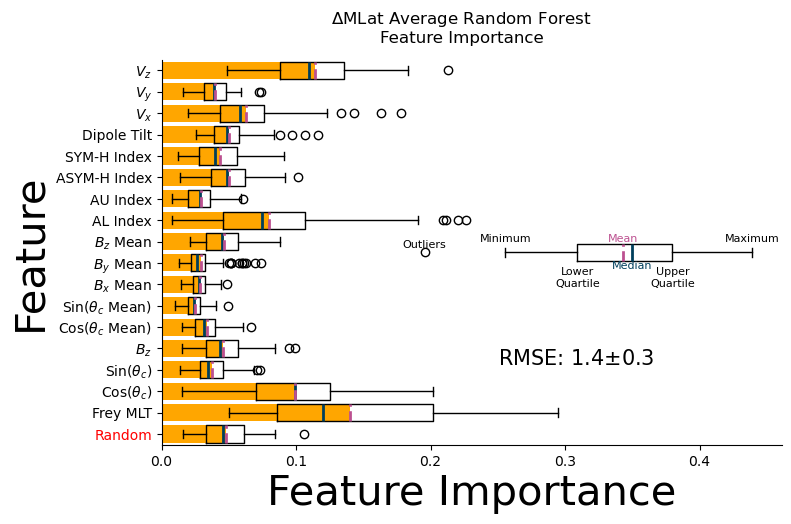

In [13]:
# mean_feature_importance contains the stable estimate of feature importance
fig= plt.figure(figsize=(8, 5))
ax=fig.add_subplot()

# Bar chart for the mean feature importance
bar= ax.barh(X.columns, mean_feature_importance, **barchart)
add_boxkey(ax, width=[round(Bar.get_bbox().height, 1) for Bar in bar.get_children()][0],
           ypos=8.5, boxplotkwargs=boxplot)

# Box plots for the feature importance distributions
ax.boxplot(all_feature_importances, vert=False, positions=range(0, len(X.columns)),
           widths= [round(Bar.get_bbox().height, 1) for Bar in bar.get_children()],
           showmeans = True, meanline = True, **boxplot)
# RMSE mean and standard deviation
ax.text(.25, 3.5, rf'RMSE: {metrics_summary["RMSE"][0]:.1f}$\pm${metrics_summary["RMSE"][1]:.1f}', size=15, va='center', ha='left')
# Defining Column Strings
columns= ['Random','Frey MLT','Cos($\\theta_c$)', 'Sin($\\theta_c$)',
          '$B_z$',
          'Cos($\\theta_c$ Mean)', 'Sin($\\theta_c$ Mean)',
          '$B_x$ Mean','$B_y$ Mean', '$B_z$ Mean',
          'AL Index','AU Index', 'ASYM-H Index', 'SYM-H Index', 'Dipole Tilt', r'$V_x$', r'$V_y$', r'$V_z$']

ax.set_yticks(list(range(0, len(columns))))

ax.set_yticklabels(columns)
ax.get_yticklabels()[0].set_color('r')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_ylabel('Feature', size=30)
ax.set_xlabel('Feature Importance', size=30)
fig.suptitle('$\Delta$MLat Average Random Forest\nFeature Importance')